##The dataset contains 420,551 rows and 15 columns, all of which are complete . It includes a wide range of weather-related features like temperature, pressure, humidity, wind velocity, and more.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('/content/Task 2 - Daily Weather Dataset.csv')
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/Task 2 - Daily Weather Dataset.csv')

# Rename the columns using a dictionary
new_column_names = {

    'p (mbar)': 'pressure',
    'T (degC)': 'temperature',
    'Tpot (K)': 'temp_potential',
    'Tdew (degC)': 'temp_dew',
    'rh (%)': 'relative_humidity',
    'VPmax (mbar)': 'vpmax',
    'VPact (mbar)': 'vpact',
    'VPdef (mbar)': 'vpdef',
    'sh (g/kg)': 'specific_humidity',
    'H2OC (mmol/mol)': 'h2oc',
    'rho (g/m**3)': 'air_density',
    'wv (m/s)': 'wind_velocity',
    'max. wv (m/s)': 'max_wind_velocity',
    'wd (deg)': 'wind_direction'
}

df = df.rename(columns=new_column_names)

# Save the DataFrame with renamed columns back to the CSV file
# df.to_csv('/content/Task 2 - Daily Weather Dataset_renamed.csv', index=False)

## Target
Predict future temperature values using past weather features.

####Data Exploration and Preprocessing

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61429 entries, 0 to 61428
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date Time          61429 non-null  object 
 1   pressure           61429 non-null  float64
 2   temperature        61429 non-null  float64
 3   temp_potential     61429 non-null  float64
 4   temp_dew           61429 non-null  float64
 5   relative_humidity  61429 non-null  float64
 6   vpmax              61429 non-null  float64
 7   vpact              61429 non-null  float64
 8   vpdef              61429 non-null  float64
 9   specific_humidity  61429 non-null  float64
 10  h2oc               61429 non-null  float64
 11  air_density        61429 non-null  float64
 12  wind_velocity      61429 non-null  float64
 13  max_wind_velocity  61429 non-null  float64
 14  wind_direction     61429 non-null  float64
dtypes: float64(14), object(1)
memory usage: 7.0+ MB


In [5]:
df.isnull().sum()

,0
Date Time,0
pressure,0
temperature,0
temp_potential,0
temp_dew,0
relative_humidity,0
vpmax,0
vpact,0
vpdef,0
specific_humidity,0


In [6]:
df.describe()

,pressure,temperature,temp_potential,temp_dew,relative_humidity,vpmax,vpact,vpdef,specific_humidity,h2oc,air_density,wind_velocity,max_wind_velocity,wind_direction
count,61429.000000,61429.000000,61429.000000,61429.000000,61429.000000,61429.000000,61429.000000,61429.000000,61429.000000,61429.000000,61429.000000,61429.000000,61429.000000,61429.000000
mean,987.307991,7.145280,281.333391,3.158382,77.998211,11.892994,8.581719,3.311196,5.425890,8.688080,1224.288366,2.143082,3.518819,172.897124
std,9.246391,9.048599,9.034101,7.423041,15.405052,7.190552,4.119937,4.218160,2.606372,4.159447,42.113169,1.551582,2.311280,87.334913
min,944.580000,-23.010000,250.600000,-25.010000,29.930000,0.950000,0.790000,0.000000,0.500000,0.800000,1120.990000,0.000000,0.000000,0.000000
25%,982.280000,0.290000,274.770000,-1.860000,68.390000,6.240000,5.330000,0.640000,3.380000,5.430000,1194.790000,1.010000,1.800000,127.300000
50%,988.510000,7.090000,281.510000,3.550000,81.600000,10.090000,7.880000,1.610000,4.990000,8.000000,1219.550000,1.840000,3.040000,195.400000
75%,993.930000,13.970000,287.950000,8.940000,90.300000,15.980000,11.440000,4.180000,7.220000,11.550000,1252.280000,2.880000,4.650000,232.800000
max,1012.470000,32.980000,306.920000,19.390000,100.000000,50.310000,22.550000,34.770000,14.250000,22.720000,1383.380000,14.630000,23.500000,360.000000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['Date Time', 'pressure', 'temperature', 'temp_potential', 'temp_dew',
       'relative_humidity', 'vpmax', 'vpact', 'vpdef', 'specific_humidity',
       'h2oc', 'air_density', 'wind_velocity', 'max_wind_velocity',
       'wind_direction'],
      dtype='object')

In [9]:
import pandas as pd
import numpy as np
#convert negative to postive
# Assuming 'df' is your DataFrame
for i in df.columns:
    if df[i].dtype in [np.int64, np.float64]:
        df[i] = df[i].abs()

df.head()

,Date Time,pressure,temperature,temp_potential,temp_dew,relative_humidity,vpmax,vpact,vpdef,specific_humidity,h2oc,air_density,wind_velocity,max_wind_velocity,wind_direction
0,01.01.2009 00:10:00,996.52,8.02,265.40,8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,8.41,265.01,9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,8.51,264.91,9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,8.31,265.12,9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,8.27,265.15,9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [10]:
df['Date Time'] = pd.to_datetime(df['Date Time'], format="%d.%m.%Y %H:%M:%S")
df["day"]=df['Date Time'].dt.day
df["month"]=df['Date Time'].dt.month
df["year"]=df['Date Time'].dt.year
df['hour']=df['Date Time'].dt.hour
df.head()

,Date Time,pressure,temperature,temp_potential,temp_dew,relative_humidity,vpmax,vpact,vpdef,specific_humidity,h2oc,air_density,wind_velocity,max_wind_velocity,wind_direction,day,month,year,hour
0,2009-01-01 00:10:00,996.52,8.02,265.40,8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3,1,1,2009,0
1,2009-01-01 00:20:00,996.57,8.41,265.01,9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1,1,1,2009,0
2,2009-01-01 00:30:00,996.53,8.51,264.91,9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6,1,1,2009,0
3,2009-01-01 00:40:00,996.51,8.31,265.12,9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0,1,1,2009,0
4,2009-01-01 00:50:00,996.51,8.27,265.15,9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3,1,1,2009,0


In [11]:
# df.drop('Date Time',axis=1,inplace=True)
# df.head()

##Visualize




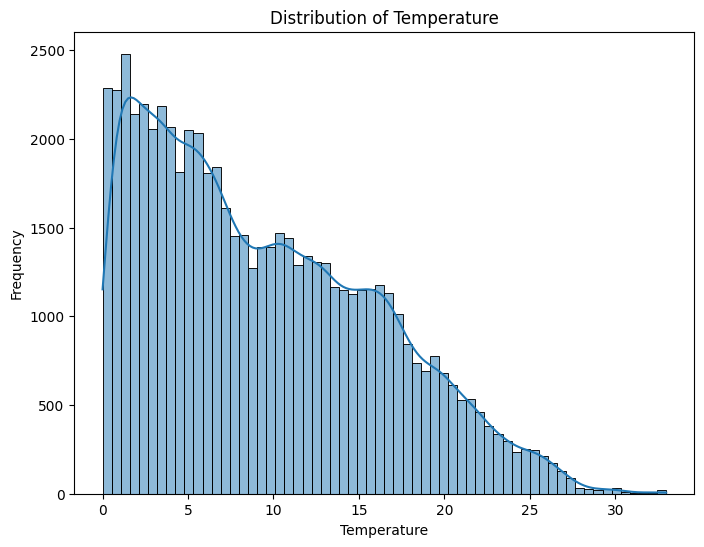

In [12]:
# Histogram for 'temperature'
plt.figure(figsize=(8, 6))
sns.histplot(df['temperature'], kde=True)  # kde adds a kernel density estimate curve
plt.title('Distribution of Temperature')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

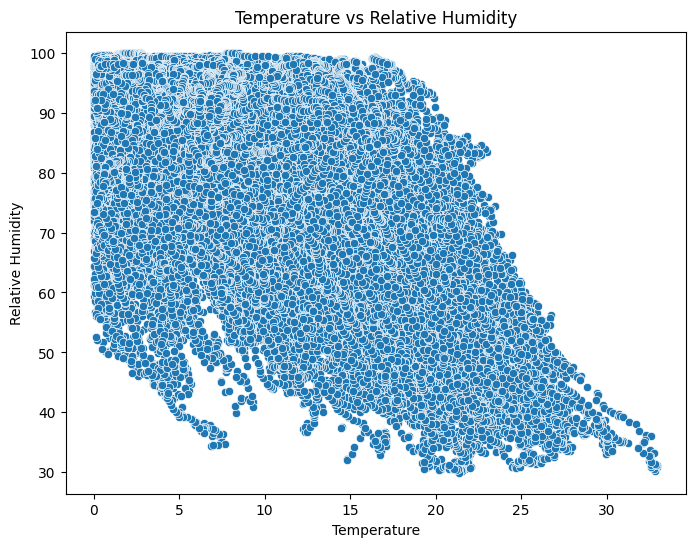

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='temperature', y='relative_humidity', data=df)
plt.xlabel('Temperature')
plt.ylabel('Relative Humidity')
plt.title('Temperature vs Relative Humidity')
plt.show()

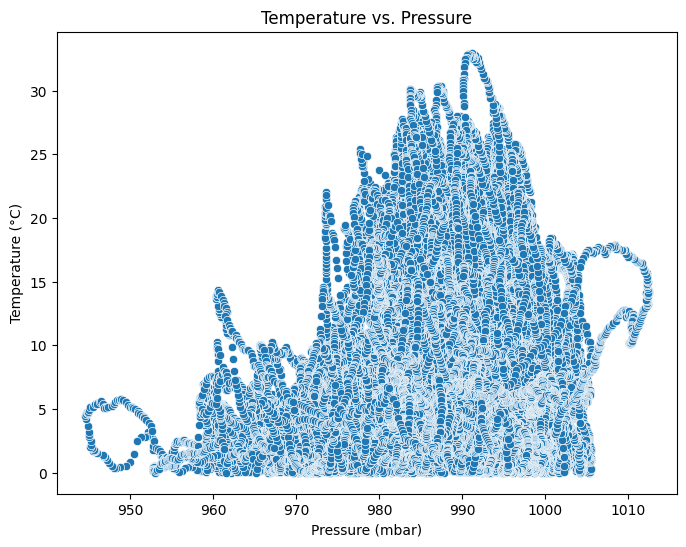

In [14]:
# 2. Scatter plot between 'temperature' and 'pressure'
plt.figure(figsize=(8, 6))
sns.scatterplot(x='pressure', y='temperature', data=df)
plt.title('Temperature vs. Pressure')
plt.xlabel('Pressure (mbar)')
plt.ylabel('Temperature (°C)')
plt.show()

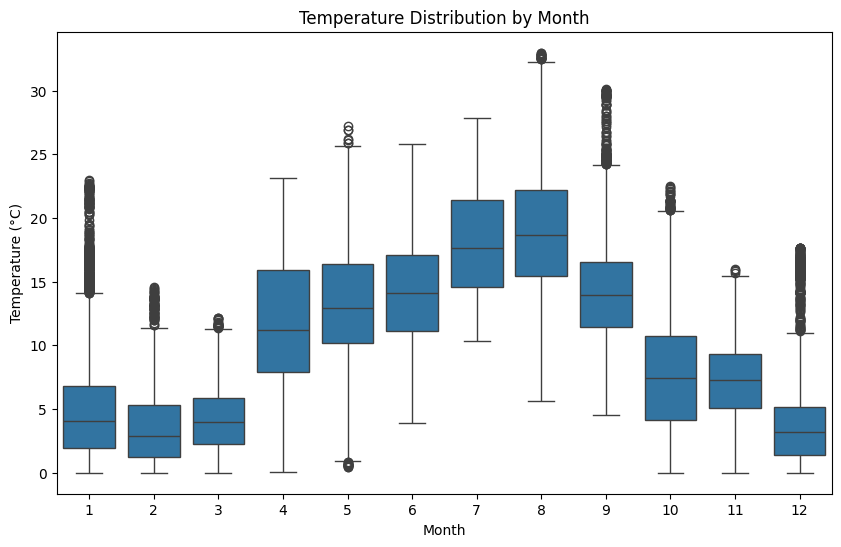

In [15]:
# 3. Box plot of 'temperature' across different months
plt.figure(figsize=(10, 6))
sns.boxplot(x='month', y='temperature', data=df)
plt.title('Temperature Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.show()

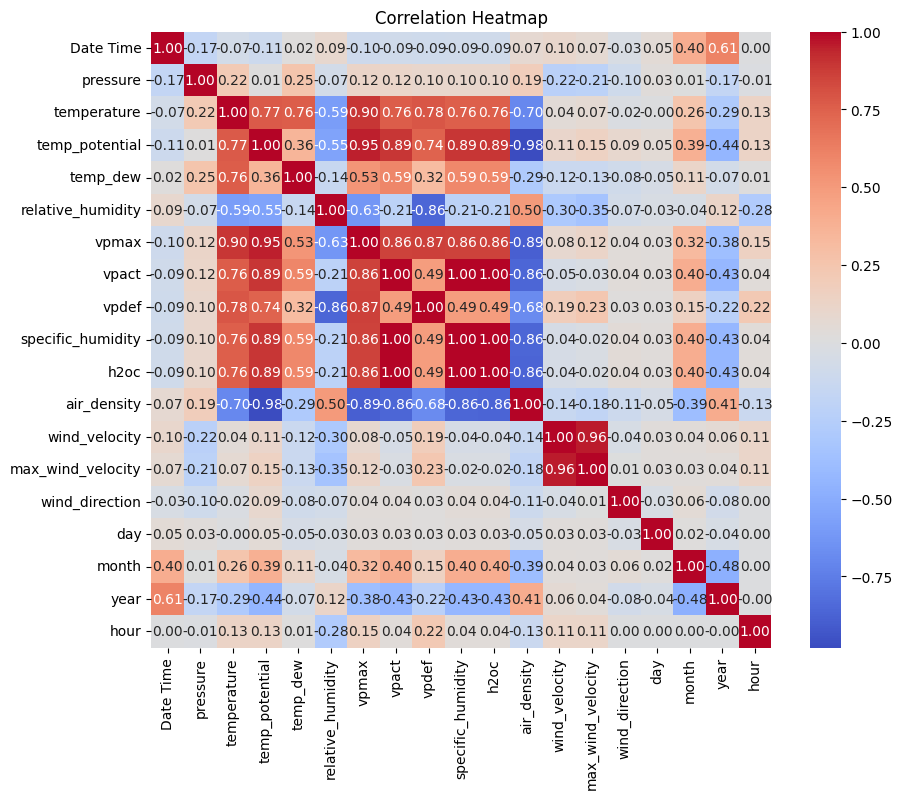

In [16]:
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [22]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Assuming 'df' is your DataFrame
features = ['pressure', 'temp_potential', 'temp_dew', 'relative_humidity', 'vpmax', 'vpact', 'vpdef', 'specific_humidity', 'h2oc', 'air_density', 'wind_velocity', 'max_wind_velocity', 'wind_direction','day','month','year','hour']
target = 'temperature'
sample_df = df.head(50000)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(sample_df[features + [target]])
# Create a new DataFrame with scaled data
scaled_df = pd.DataFrame(scaled_data, columns=features + [target])

# Accessing columns using column names
X = scaled_df[features]
y = scaled_df[target]

# ... (rest of your code)

In [24]:
# ... (previous code)
from sklearn.model_selection import train_test_split
# Fit and transform the data
scaled_data = scaler.fit_transform(sample_df[features + [target]])

# Create a new DataFrame with scaled data
scaled_df = pd.DataFrame(scaled_data, columns=features + [target])

# Split the data into training and testing sets
X = scaled_df[features]
y = scaled_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ... (rest of your code)

In [25]:
X

,pressure,temp_potential,temp_dew,relative_humidity,vpmax,vpact,vpdef,specific_humidity,h2oc,air_density,wind_velocity,max_wind_velocity,wind_direction,day,month,year,hour
0,0.849665,0.262784,0.355858,0.904381,0.048217,0.106618,0.006327,0.104727,0.105839,0.711765,0.079475,0.092986,0.423056,0.000000,0.0,0.0,0.000000
1,0.850483,0.255859,0.371052,0.905808,0.046191,0.102482,0.006040,0.101091,0.101734,0.719578,0.055556,0.079702,0.378056,0.000000,0.0,0.0,0.000000
2,0.849828,0.254084,0.372251,0.912944,0.045786,0.102022,0.005752,0.100364,0.101277,0.721255,0.014660,0.033475,0.476667,0.000000,0.0,0.0,0.000000
3,0.849501,0.257812,0.362655,0.917226,0.046799,0.104779,0.005464,0.103273,0.104015,0.717253,0.026235,0.026567,0.550000,0.000000,0.0,0.0,0.000000
4,0.849501,0.258345,0.361455,0.915798,0.047002,0.105239,0.005464,0.103273,0.104471,0.716529,0.024691,0.033475,0.595278,0.000000,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0.839195,0.329013,0.264294,0.773084,0.070300,0.134651,0.020132,0.133091,0.133668,0.639354,0.272377,0.268332,0.086361,0.433333,1.0,0.0,0.217391
49996,0.837396,0.329901,0.261495,0.775938,0.070502,0.135570,0.020132,0.133818,0.134580,0.638134,0.233025,0.227949,0.078500,0.433333,1.0,0.0,0.217391
49997,0.837396,0.330078,0.263095,0.771657,0.070705,0.135110,0.020420,0.133091,0.134124,0.637982,0.212963,0.236451,0.098722,0.433333,1.0,0.0,0.217391
49998,0.837723,0.330966,0.268693,0.753104,0.071110,0.133272,0.022146,0.131636,0.132299,0.637067,0.199846,0.202444,0.129028,0.433333,1.0,0.0,0.217391


In [26]:
y

,temperature
0,0.243178
1,0.255003
2,0.258035
3,0.251971
4,0.250758
...,...
49995,0.131898
49996,0.130685
49997,0.130382
49998,0.128563


##model

In [34]:
sequence_length = 24
X, y = [], []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, :-1])  # كل الصفوف في الـ 24 خطوة، ماعدا الهدف
    y.append(scaled_data[i, -1])  # درجة الحرارة فقط

X = np.array(X)
y = np.array(y)


In [36]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [40]:
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

history = model.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.1)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0175 - val_loss: 0.0019
Epoch 2/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0024 - val_loss: 0.0016
Epoch 3/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0018 - val_loss: 9.1748e-04
Epoch 4/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0014 - val_loss: 6.5403e-04
Epoch 5/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0011 - val_loss: 5.7249e-04
Epoch 6/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 9.1269e-04 - val_loss: 4.0630e-04
Epoch 7/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.5877e-04 - val_loss: 4.1447e-04
Epoch 8/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6.6785e-04 - val_loss: 2.9570e-04
Epoch 9/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.7570e-04 - val_loss: 2.6115e-04
Epoch 10/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.1508e-04 - val_loss: 2.3103e-04
Epoch 11/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 4.9866e-04 - val_loss: 1.8

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
📊 RMSE: 0.35
📊 MAE: 0.28


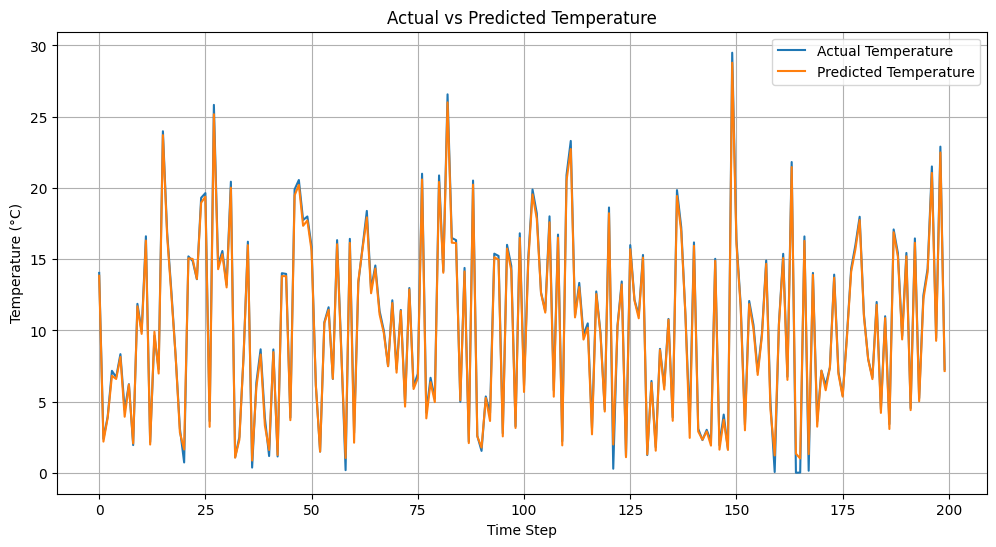

In [41]:
# التنبؤ
y_pred = model.predict(X_test)

# فك الترميز (inverse transform)
y_test_reshaped = np.array(y_test).reshape(-1, 1)
y_pred_reshaped = np.array(y_pred).reshape(-1, 1)
dummy_test = np.zeros((len(y_test), len(features)))
dummy_pred = np.zeros((len(y_pred), len(features)))

test_full = np.hstack((dummy_test, y_test_reshaped))
pred_full = np.hstack((dummy_pred, y_pred_reshaped))

y_test_real = scaler.inverse_transform(test_full)[:, -1]
y_pred_real = scaler.inverse_transform(pred_full)[:, -1]

# المقاييس
mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_real, y_pred_real)

print(f"📊 RMSE: {rmse:.2f}")
print(f"📊 MAE: {mae:.2f}")

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(y_test_real[:200], label='Actual Temperature')
plt.plot(y_pred_real[:200], label='Predicted Temperature')
plt.title('Actual vs Predicted Temperature')
plt.xlabel('Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()


## model with GRU

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

# بناء الموديل باستخدام GRU
model = Sequential()
model.add(GRU(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# تدريب الموديل
history = model.fit(X_train, y_train, epochs=40, batch_size=64, validation_split=0.1)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 64)             │        15,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,001 (62.50 KB)

 Trainable params: 16,001 (62.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0212 - val_loss: 0.0019
Epoch 2/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0028 - val_loss: 0.0015
Epoch 3/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 4/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0017 - val_loss: 7.7763e-04
Epoch 5/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0013 - val_loss: 5.4302e-04
Epoch 6/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0010 - val_loss: 4.1895e-04
Epoch 7/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.4071e-04 - val_loss: 3.2170e-04
Epoch 8/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.1785e-04 - val_loss: 2.6136e-04
Epoch 9/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 6.2001e-04 - val_loss: 2.1734e-04
Epoch 10/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.5392e-04 - val_loss: 2.0791e-04
Epoch 11/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.2465e-04 - val_loss: 1.8372e-04


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
📊 RMSE: 0.32
📊 MAE: 0.21


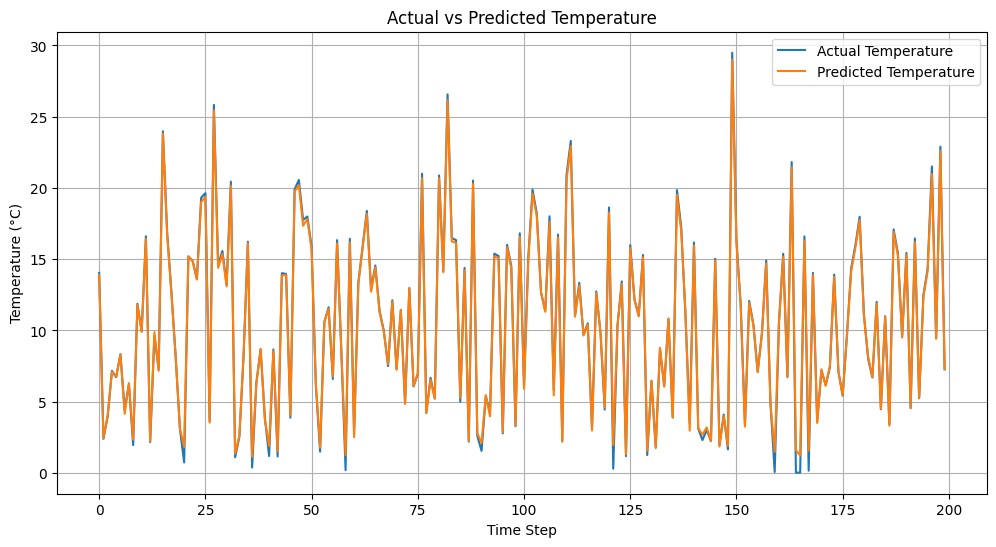

In [47]:
# التنبؤ
y_pred = model.predict(X_test)

# فك الترميز (inverse transform)
y_test_reshaped = np.array(y_test).reshape(-1, 1)
y_pred_reshaped = np.array(y_pred).reshape(-1, 1)
dummy_test = np.zeros((len(y_test), len(features)))
dummy_pred = np.zeros((len(y_pred), len(features)))

test_full = np.hstack((dummy_test, y_test_reshaped))
pred_full = np.hstack((dummy_pred, y_pred_reshaped))

y_test_real = scaler.inverse_transform(test_full)[:, -1]
y_pred_real = scaler.inverse_transform(pred_full)[:, -1]

# المقاييس
mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_real, y_pred_real)

print(f"📊 RMSE: {rmse:.2f}")
print(f"📊 MAE: {mae:.2f}")

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(y_test_real[:200], label='Actual Temperature')
plt.plot(y_pred_real[:200], label='Predicted Temperature')
plt.title('Actual vs Predicted Temperature')
plt.xlabel('Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()
